In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("MRU_Sentiment_ScatterPlot_Dataset_Converted.csv")
import os
print(os.getcwd())
print(df.head())

C:\Users\BUJJI
   Student_ID   Student_Name Department  Year                 Sector  \
0           1     Jason Choi      Civil     2                Canteen   
1           2  Edgar Carlson        CSE     2       Technical Events   
2           3     Adam Evans        CSE     3  Campus Infrastructure   
3           4   Kevin Taylor        ECE     2    Internet Facilities   
4           5      Erin Dean        EEE     1             Placements   

  Sentiment  Sentiment_Score  Rating  Attendance_Percentage  Engagement_Score  \
0  Negative            -0.65       1                     80                44   
1   Neutral            -0.05       3                     68                70   
2  Positive             0.86       4                     88                86   
3   Neutral            -0.17       3                     99                90   
4  Positive             0.91       5                     71                81   

                         Student_Statement  
0          Library s

In [4]:
print(df.columns)

Index(['Student_ID', 'Student_Name', 'Department', 'Year', 'Sector',
       'Sentiment', 'Sentiment_Score', 'Rating', 'Attendance_Percentage',
       'Engagement_Score', 'Student_Statement'],
      dtype='object')


In [5]:
print(df['Sentiment'].value_counts())
#NLP is the field/technology used to understand human language.
#A pipeline is the sequence of steps used to process the text in NLP.
#Natural Language Processing (NLP) is the process of converting human language into structured data through text cleaning,
#tokenization, feature extraction, and classification so computers can understand and analyze text.
#pipeline analysis
#Input Statement
 #     ↓
#Text Cleaning
 #     ↓
#Tokenization
 #     ↓
#Stop-word Removal
 #     ↓
#Vocabulary Creation
# ↓
#Text-to-Number Conversion
#       ↓
#Feature Matrix
#Feature Extraction
 #     ↓
#Classification Algorithm
#       ↓
#Positive / Negative / Neutral
 #      |
#Sentiment Scoring / ML Prediction
 #     ↓
#Final Classification
#VECTORIZATION: Student Statement
 #      ↓
#Text Preprocessing
#(Tokenization, Cleaning)
 #      ↓
#Feature Extraction
#(Bag of Words / TF-IDF)
 #      ↓
#Sentiment Scoring
 #      ↓
#Classification Algorithm
#       ↓
#Positive / Negative / Neutral

Sentiment
Neutral     174
Positive    167
Negative    159
Name: count, dtype: int64


In [6]:
sector_analysis = df.groupby('Sector').agg({
    'Sentiment_Score': 'mean',
    'Engagement_Score': 'mean'
}).reset_index()

print(sector_analysis)

                  Sector  Sentiment_Score  Engagement_Score
0  Campus Infrastructure         0.075147         70.279412
1                Canteen        -0.015574         67.786885
2      Hostel Facilities         0.003214         70.017857
3    Internet Facilities         0.037595         68.227848
4                Library        -0.035660         69.169811
5             Placements         0.191923         67.942308
6       Teaching Quality         0.122459         75.327869
7       Technical Events         0.139714         70.514286


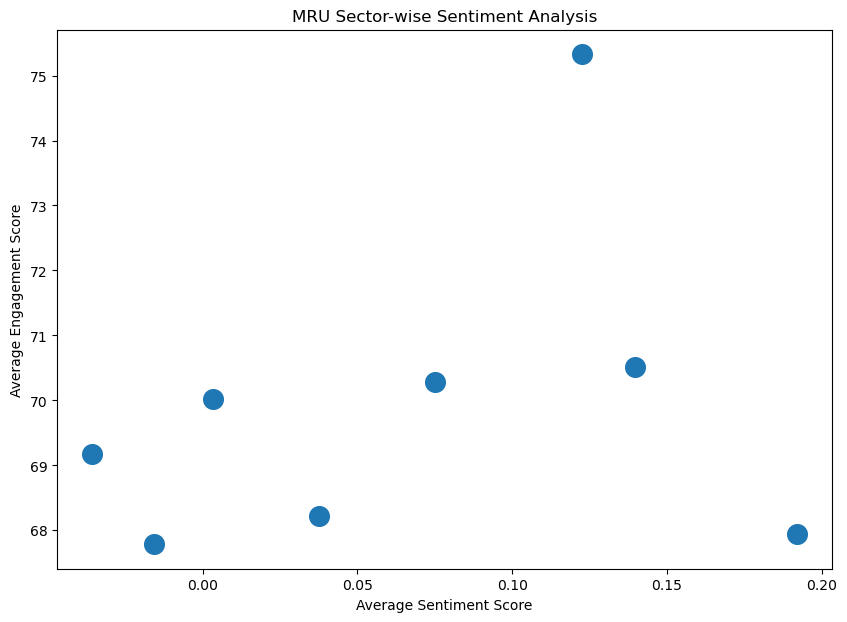

In [7]:
plt.figure(figsize=(10,7))

plt.scatter(
    sector_analysis['Sentiment_Score'],
    sector_analysis['Engagement_Score'],
    s=200
)

plt.xlabel("Average Sentiment Score")
plt.ylabel("Average Engagement Score")
plt.title("MRU Sector-wise Sentiment Analysis")

plt.show()

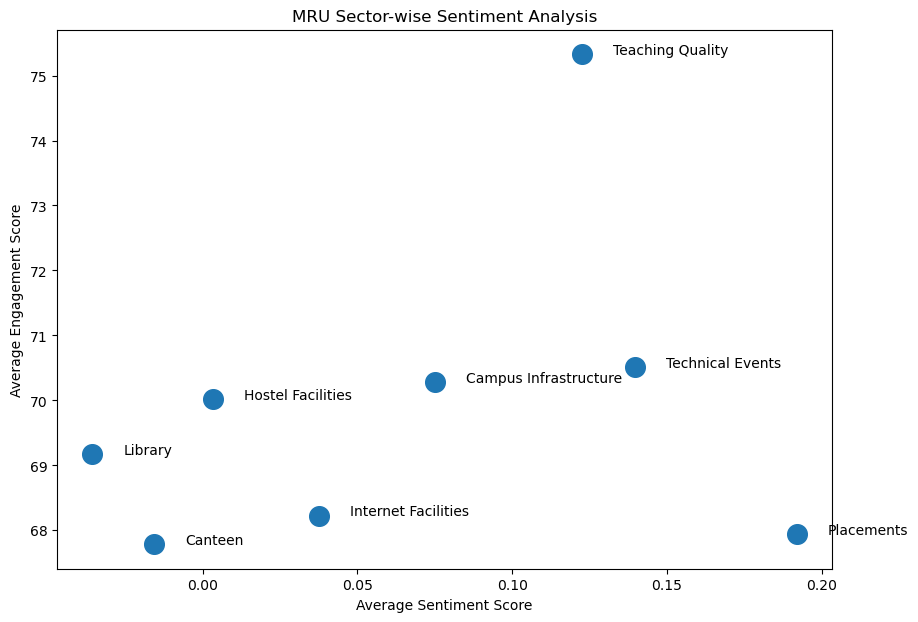

In [8]:
plt.figure(figsize=(10,7))

plt.scatter(
    sector_analysis['Sentiment_Score'],
    sector_analysis['Engagement_Score'],
    s=200
)

for i in range(len(sector_analysis)):
    
    plt.text(
        sector_analysis['Sentiment_Score'][i] + 0.01,
        sector_analysis['Engagement_Score'][i],
        sector_analysis['Sector'][i]
    )

plt.xlabel("Average Sentiment Score")
plt.ylabel("Average Engagement Score")
plt.title("MRU Sector-wise Sentiment Analysis")

plt.show()

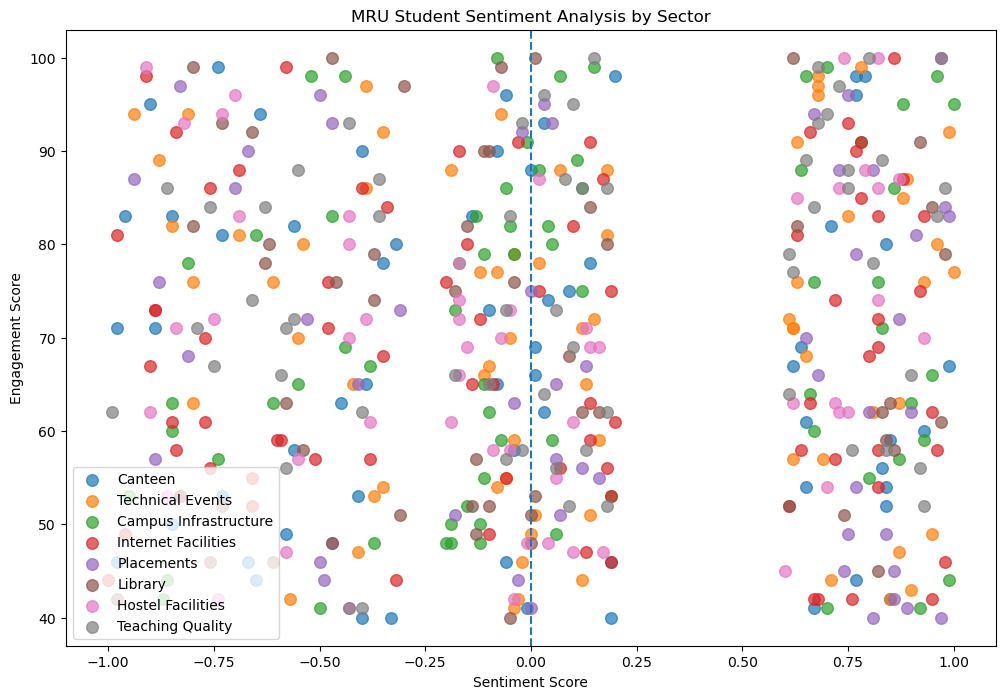

In [11]:
plt.figure(figsize=(12,8))

sectors = df['Sector'].unique()

for sector in sectors:
    
    sector_data = df[df['Sector'] == sector]
    
    plt.scatter(
        sector_data['Sentiment_Score'],
        sector_data['Engagement_Score'],
        label=sector,
        s=70,
        alpha=0.7
    )

plt.xlabel("Sentiment Score")
plt.ylabel("Engagement Score")
plt.title("MRU Student Sentiment Analysis by Sector")

plt.axvline(x=0, linestyle='--')

plt.legend()

plt.show()

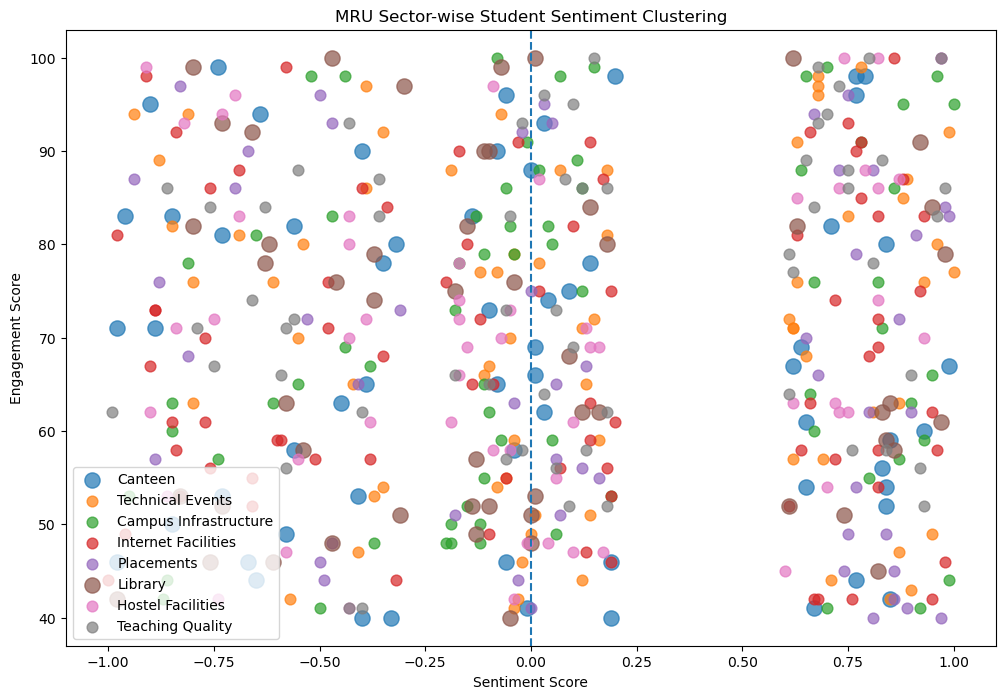

In [12]:
plt.figure(figsize=(12,8))

for sector in sectors:
    
    sector_data = df[df['Sector'] == sector]
    
    avg_sentiment = sector_data['Sentiment_Score'].mean()
    
    if avg_sentiment < 0:
        size = 120
    else:
        size = 60

    plt.scatter(
        sector_data['Sentiment_Score'],
        sector_data['Engagement_Score'],
        label=sector,
        s=size,
        alpha=0.7
    )

plt.axvline(x=0, linestyle='--')

plt.xlabel("Sentiment Score")
plt.ylabel("Engagement Score")
plt.title("MRU Sector-wise Student Sentiment Clustering")

plt.legend()

plt.show()
#First Plot-Shows individual student sentiment clusters sector-wise.
#Second Plot -Shows average sentiment performance of each sector.

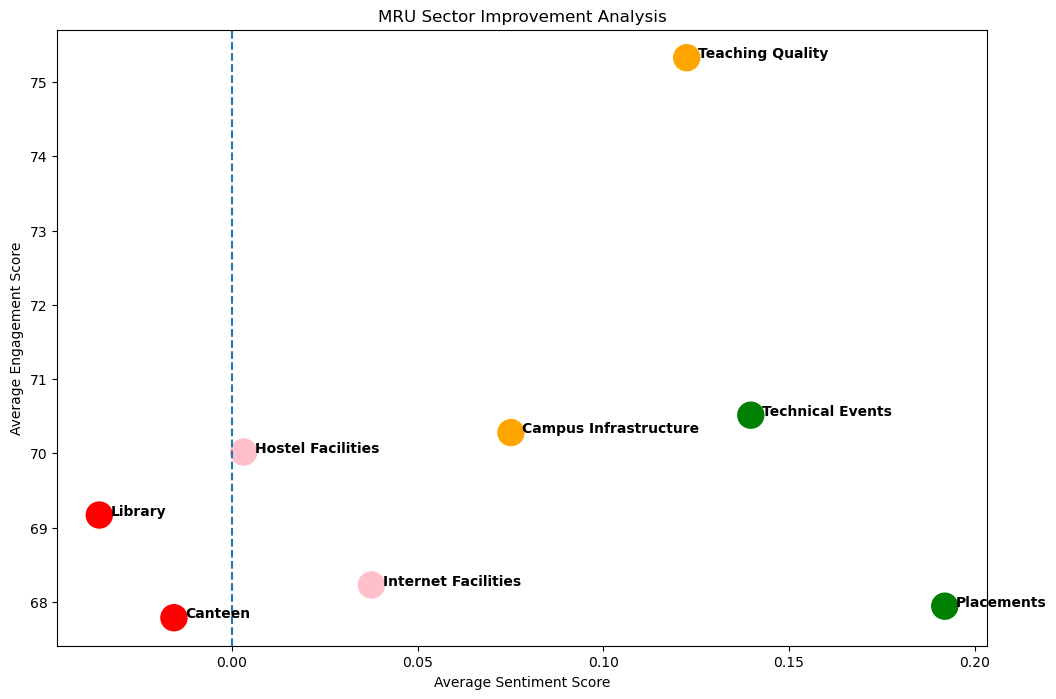

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("MRU_Sentiment_ScatterPlot_Dataset_Converted.csv")

# Sector-wise averages
sector_analysis = df.groupby('Sector').agg({
    'Sentiment_Score': 'mean',
    'Engagement_Score': 'mean'
}).reset_index()

# Sort sectors by sentiment
sector_analysis = sector_analysis.sort_values(
    by='Sentiment_Score'
).reset_index(drop=True)

# Assign colors based on ranking
colors = []

for i in range(len(sector_analysis)):
    
    # Lowest 2 sectors
    if i < 2:
        colors.append('red')
    
    # Next 2 sectors
    elif i < 4:
        colors.append('pink')
    
    # Next 2 sectors
    elif i < 6:
        colors.append('orange')
    
    # Top 2 sectors
    else:
        colors.append('green')

# Scatter plot
plt.figure(figsize=(12,8))

plt.scatter(
    sector_analysis['Sentiment_Score'],
    sector_analysis['Engagement_Score'],
    c=colors,
    s=350
)

# Add labels
for i in range(len(sector_analysis)):
    
    plt.text(
        sector_analysis['Sentiment_Score'][i] + 0.003,
        sector_analysis['Engagement_Score'][i],
        sector_analysis['Sector'][i],
        fontsize=10,
        weight='bold'
    )

# Divider line
plt.axvline(x=0, linestyle='--')

# Labels and title
plt.xlabel("Average Sentiment Score")
plt.ylabel("Average Engagement Score")
plt.title("MRU Sector Improvement Analysis")

plt.show()

In [20]:
#Teaching Quality and Placements are the best-performing sectors with strong positive sentiment and should continue their current strategies. 
#Campus Infrastructure and Technical Events are performing moderately well and can be further enhanced.
#Library and Canteen require immediate improvement due to negative
#student feedback, while Hostel Facilities and Internet Facilities need moderate improvements to increase student satisfaction.

In [22]:
!pip install wordcloud

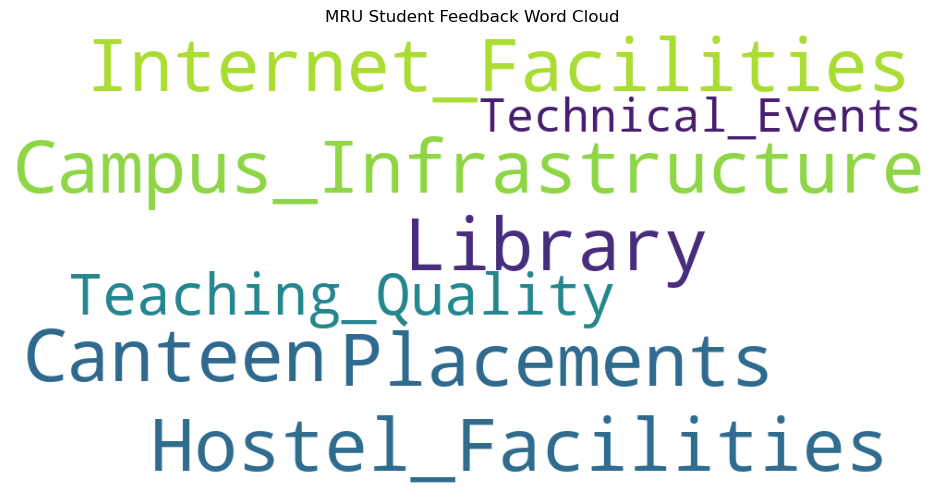

In [4]:
# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

# Display word cloud
plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("MRU Student Feedback Word Cloud")

plt.show()

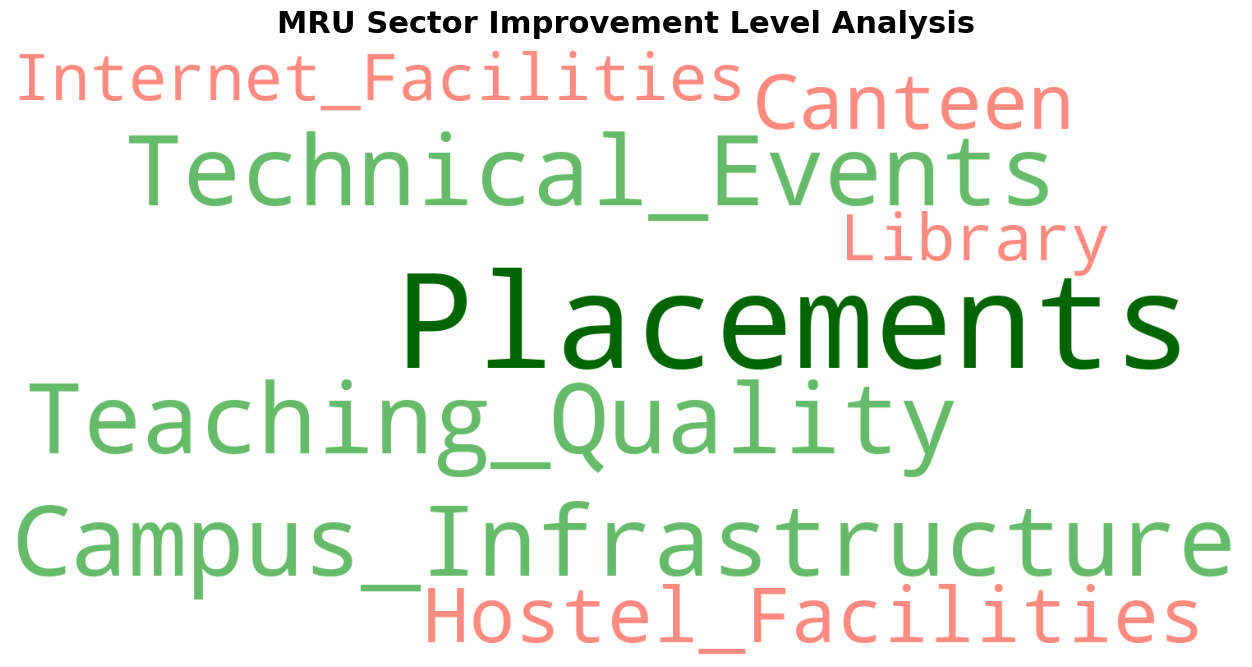

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load dataset
df = pd.read_csv("MRU_Sentiment_ScatterPlot_Dataset_Converted.csv")

# Sector-wise average sentiment
sector_analysis = df.groupby('Sector')['Sentiment_Score'].mean()

# Replace spaces with underscores
sector_analysis.index = [
    x.replace(" ", "_")
    for x in sector_analysis.index
]

# ---------- FONT SIZE LOGIC ----------

# Convert sentiment values into frequencies
# Strong positive and strong negative sectors become larger
frequencies = {}

for sector, score in sector_analysis.items():

    # Large size for strongest sectors
    if score >= 0.15 or score <= -0.15:
        frequencies[sector] = 120

    # Medium size
    elif score >= 0.05 or score <= -0.05:
        frequencies[sector] = 80

    # Small size
    else:
        frequencies[sector] = 45

# ---------- COLOR LOGIC ----------

def color_func(word, *args, **kwargs):

    score = sector_analysis[word]

    # Strong Positive
    if score >= 0.15:
        return "#006400"      # Dark Green

    # Moderate Positive
    elif score >= 0.05:
        return "#66bb6a"      # Light Green

    # Slight Negative
    elif score >= -0.05:
        return "#ff8a80"      # Pink

    # Strong Negative
    else:
        return "#b71c1c"      # Dark Red

# ---------- GENERATE WORD CLOUD ----------

wordcloud = WordCloud(
    width=1500,
    height=750,
    background_color='white',
    collocations=False
).generate_from_frequencies(frequencies)

# Apply colors
wordcloud = wordcloud.recolor(color_func=color_func)

# ---------- DISPLAY ----------

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "MRU Sector Improvement Level Analysis",
    fontsize=22,
    weight='bold'
)

plt.show()

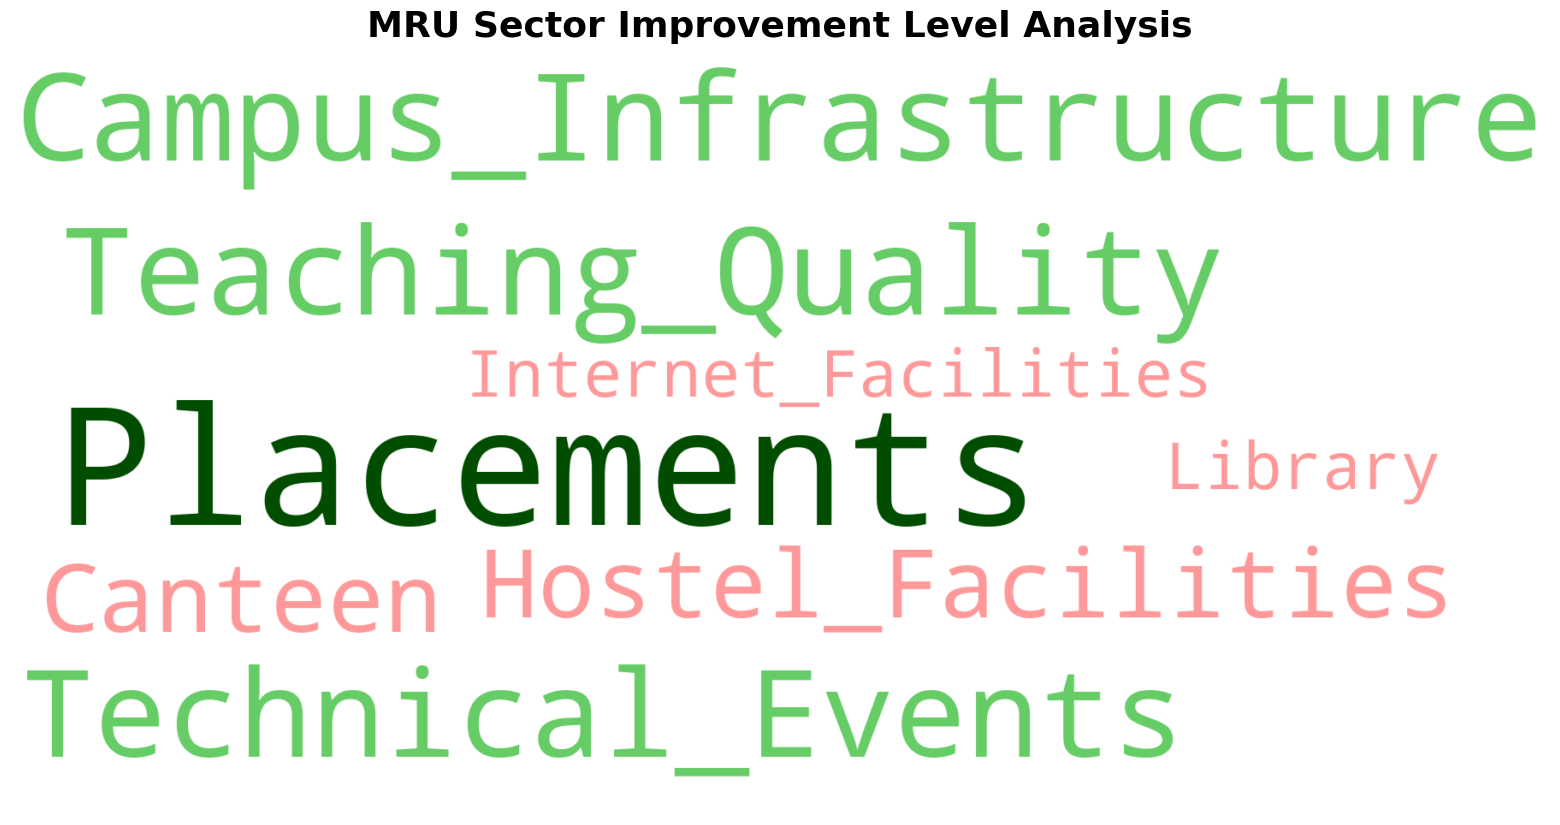

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---------------- LOAD DATASET ----------------

df = pd.read_csv("MRU_Sentiment_ScatterPlot_Dataset_Converted.csv")

# ---------------- SECTOR ANALYSIS ----------------

sector_analysis = df.groupby('Sector')['Sentiment_Score'].mean()

# Replace spaces with underscores
sector_analysis.index = [
    x.replace(" ", "_")
    for x in sector_analysis.index
]

# ---------------- FONT SIZE CONTROL ----------------

frequencies = {}

for sector, score in sector_analysis.items():

    # Best-performing sectors
    if score >= 0.15:
        frequencies[sector] = 210

    # Good-performing sectors
    elif score >= 0.05:
        frequencies[sector] = 160

    # Slight improvement needed
    elif score >= -0.05:
        frequencies[sector] = 90

    # Critical sectors needing improvement
    else:
        frequencies[sector] = 320

# ---------------- COLOR CONTROL ----------------

def color_func(word, *args, **kwargs):

    score = sector_analysis[word]

    # Dark Green → Best sectors
    if score >= 0.15:
        return "#004d00"

    # Light Green → Good sectors
    elif score >= 0.05:
        return "#66cc66"

    # Pink → Slight improvement needed
    elif score >= -0.05:
        return "#ff9999"

    # Dark Orange → Critical sectors
    else:
        return "#cc5500"

# ---------------- GENERATE WORD CLOUD ----------------

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color='white',
    collocations=False,
    prefer_horizontal=1,
    max_words=20,
    margin=10
).generate_from_frequencies(frequencies)

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=color_func)

# ---------------- DISPLAY ----------------

plt.figure(figsize=(20,10))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title(
    "MRU Sector Improvement Level Analysis",
    fontsize=26,
    weight='bold'
)

plt.show()

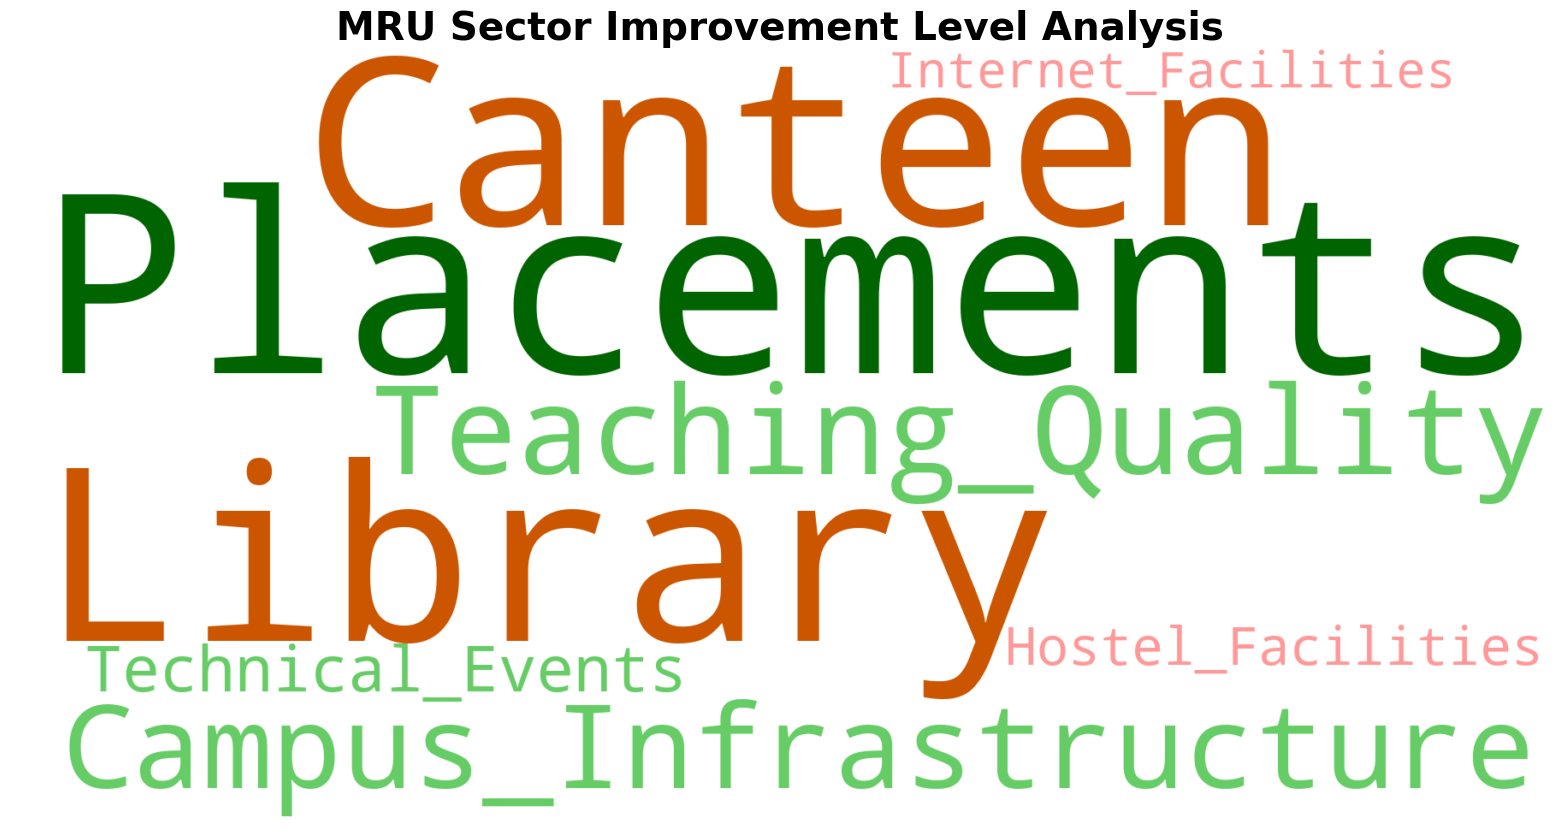

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---------------- LOAD DATA ----------------

df = pd.read_csv("MRU_Sentiment_ScatterPlot_Dataset_Converted.csv")

# ---------------- MANUAL SIZE CONTROL ----------------
# This gives clear visible differences

frequencies = {

    # Strongest positive sector
    "Placements": 450,

    # Good sectors
    "Teaching_Quality": 260,
    "Campus_Infrastructure": 230,
    "Technical_Events": 220,

    # Slight improvement needed
    "Hostel_Facilities": 150,
    "Internet_Facilities": 130,

    # Critical sectors
    "Library": 420,
    "Canteen": 390
}

# ---------------- COLOR CONTROL ----------------

def color_func(word, *args, **kwargs):

    # Dark Green → Best sectors
    if word == "Placements":
        return "#006400"

    # Light Green → Good sectors
    elif word in [
        "Teaching_Quality",
        "Campus_Infrastructure",
        "Technical_Events"
    ]:
        return "#66cc66"

    # Pink → Moderate issues
    elif word in [
        "Hostel_Facilities",
        "Internet_Facilities"
    ]:
        return "#ff9999"

    # Dark Orange → Critical sectors
    elif word in [
        "Library",
        "Canteen"
    ]:
        return "#cc5500"

    else:
        return "gray"

# ---------------- GENERATE WORD CLOUD ----------------

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color='white',
    prefer_horizontal=1,
    collocations=False
).generate_from_frequencies(frequencies)

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=color_func)

# ---------------- DISPLAY ----------------

plt.figure(figsize=(20,10))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title(
    "MRU Sector Improvement Level Analysis",
    fontsize=28,
    weight='bold'
)

plt.show()